# Federal procurement analytics results

## Summary
This companion reproduces two charts from the original Databricks notebook's saved aggregate tables. It demonstrates how the SQL results can be communicated to a business audience. It does not execute the underlying 5.8-million-row transformation.

## Context and methods
The project analyzes the FY2025 contract snapshot referenced in the original notebooks. Rows are procurement transactions. Aggregate CSVs were extracted from saved HTML table outputs; provenance is recorded in `data/provenance.json`.

### Assumptions
The source snapshot's completeness and transaction uniqueness are unverified. Chart values reproduce the saved aggregate outputs. No claims of realized savings, data-accuracy improvement, or causal effects are made.

## Data

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string(index=False) if hasattr(value, "to_string") else value)

ROOT = Path.cwd()
if not (ROOT / "data" / "summary.json").exists():
    ROOT = ROOT.parent
assert (ROOT / "data" / "summary.json").exists(), "Run from the repository root or notebooks directory."
summary = json.loads((ROOT / "data" / "summary.json").read_text())
agencies = pd.read_csv(ROOT / "data" / "agency_obligations.csv")
award_types = pd.read_csv(ROOT / "data" / "award_type_transactions.csv", keep_default_na=False)
(ROOT / "images").mkdir(exist_ok=True)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

### Check the saved aggregates

In [2]:
assert summary["transaction_rows"] == summary["retained_rows"]
assert int(award_types["transaction_count"].sum()) == summary["transaction_rows"]
assert agencies["awarding_agency_name"].is_unique
assert agencies["total_obligation"].notna().all()
assert 0 <= summary["full_open_competition_transaction_pct"] <= 100
display(pd.DataFrame({"Measure": ["Transaction rows", "Source columns", "Projected columns", "Transaction obligations (USD billions)"],
                      "Saved result": [f'{summary["transaction_rows"]:,}', str(summary["source_columns"]), str(summary["retained_columns"]), f'{summary["total_obligations_usd"]/1e9:,.3f}']}))
print("Award-type counts reconcile to the saved total. This is internal consistency, not independent source verification.")

                               Measure Saved result
                      Transaction rows    5,804,212
                        Source columns          297
                     Projected columns           48
Transaction obligations (USD billions)      653.865
Award-type counts reconcile to the saved total. This is internal consistency, not independent source verification.


## Results

### Which agencies account for the largest obligations?
The chart shows the top 10 agencies returned by the original SQL query. It uses absolute USD billions and a zero baseline.

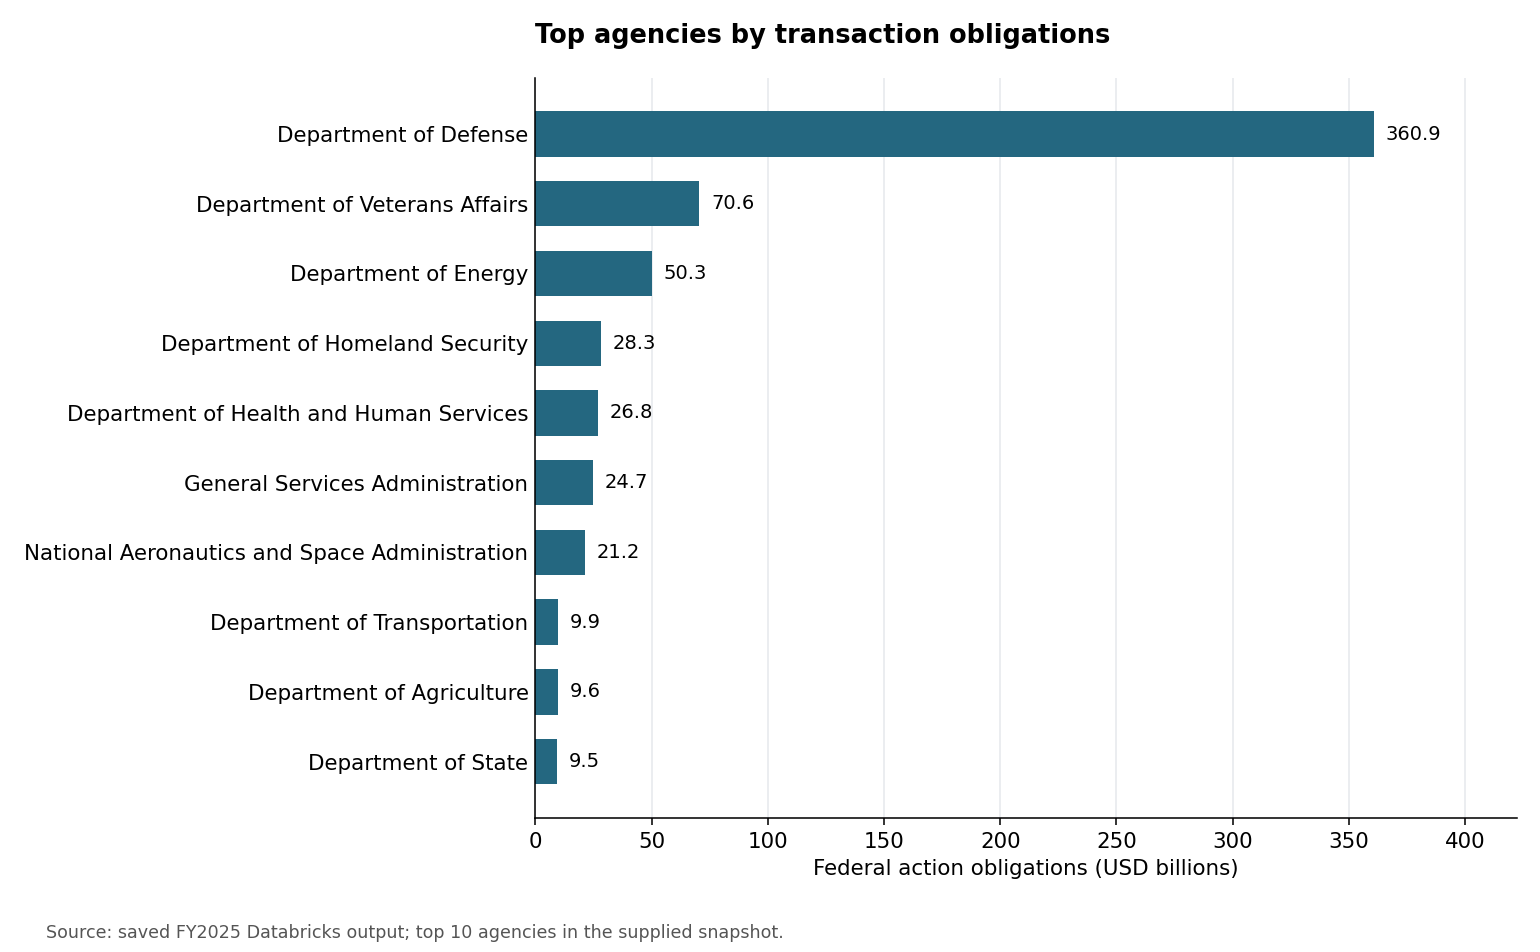

In [3]:
plot = agencies.sort_values("total_obligation")
fig, ax = plt.subplots(figsize=(11, 6.8))
bars = ax.barh(plot["awarding_agency_name"], plot["total_obligation"] / 1e9, color="#246780", height=0.65)
ax.bar_label(bars, labels=[f"{v:,.1f}" for v in plot["total_obligation"] / 1e9], padding=6, fontsize=10)
ax.set_xlim(0, plot["total_obligation"].max() / 1e9 * 1.17)
ax.set_xlabel("Federal action obligations (USD billions)")
ax.set_title("Top agencies by transaction obligations", loc="left", fontweight="bold", pad=18)
ax.xaxis.grid(True, color="#E6E9ED"); ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
fig.text(0.03, 0.015, "Source: saved FY2025 Databricks output; top 10 agencies in the supplied snapshot.", fontsize=9, color="#555555")
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(ROOT / "images" / "agency_obligations.png", dpi=160, facecolor="white")
plt.show()

In [4]:
leader = agencies.loc[agencies["total_obligation"].idxmax()]
print(f'{leader["awarding_agency_name"]} leads the saved ranking at ${leader["total_obligation"]/1e9:,.1f} billion.')

Department of Defense leads the saved ranking at $360.9 billion.


### What types of transactions make up the activity?
This chart includes every category in the saved award-type result, including missing labels. Counts describe transactions, not unique contracts.

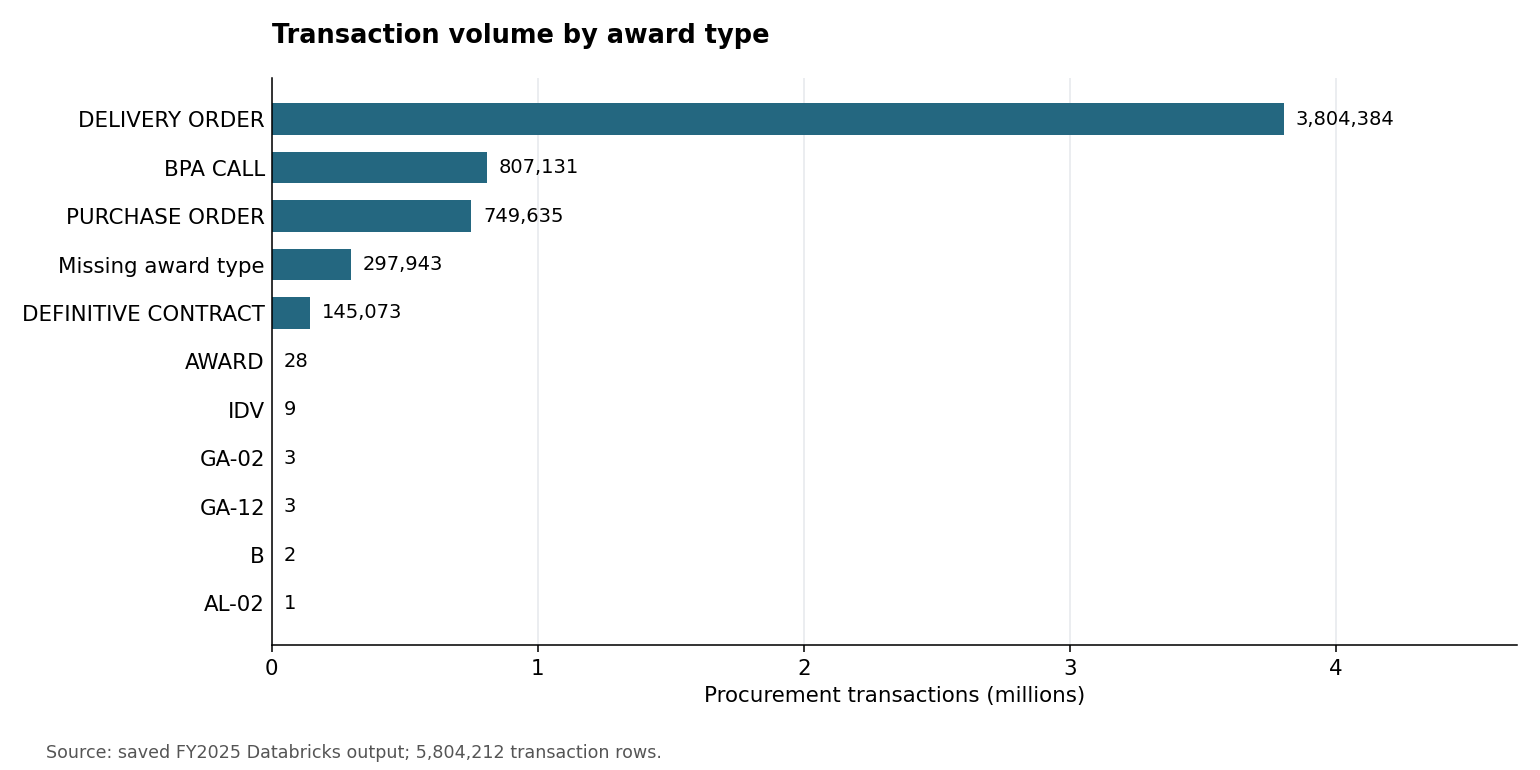

In [5]:
plot = award_types.copy()
plot["award_type"] = plot["award_type"].replace({"null": "Missing award type", "": "Missing award type"})
plot = plot.sort_values("transaction_count")
fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(plot["award_type"], plot["transaction_count"] / 1e6, color="#246780", height=0.65)
ax.bar_label(bars, labels=[f"{v:,}" for v in plot["transaction_count"]], padding=6, fontsize=10)
ax.set_xlim(0, plot["transaction_count"].max() / 1e6 * 1.23)
ax.set_xlabel("Procurement transactions (millions)")
ax.set_title("Transaction volume by award type", loc="left", fontweight="bold", pad=18)
ax.xaxis.grid(True, color="#E6E9ED"); ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
fig.text(0.03, 0.015, f'Source: saved FY2025 Databricks output; {summary["transaction_rows"]:,} transaction rows.', fontsize=9, color="#555555")
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(ROOT / "images" / "award_type_transactions.png", dpi=160, facecolor="white")
plt.show()

In [6]:
leader = award_types.loc[award_types["transaction_count"].idxmax()]
share = leader["transaction_count"] / summary["transaction_rows"] * 100
print(f'{leader["award_type"]} represents {share:.1f}% of recorded transaction rows.')

DELIVERY ORDER represents 65.5% of recorded transaction rows.


## Takeaways
Agency obligations and transaction volume answer different questions: financial exposure versus recorded activity. Together they illustrate how SQL summaries can support resource-allocation discussions, without establishing efficiency or causality.

### Validation boundary
This notebook can be executed locally from the included aggregates. Reproducing source ingestion and KPI queries requires the original CSV snapshot and Databricks. The full raw extract is not included. See `docs/limitations.md` and `docs/reproduce.md`.